# [IAPR][iapr]: Final project - Chocolate Recognition


**Moodle group ID:** *17*  
**Kaggle challenge:** *Classic* (either `Classic` or `Deep learning`)  
**Kaggle team name (exact):** "*Willy Wonka's Oompa Loompas*"  


**Author 1 (SCIPER):** *Timo Michoud (302039)*  
**Author 2 (SCIPER):** *Sina Röllin (315645)*  
**Author 3 (SCIPER):** *Veronika Podliesnova (390236)*  


**Due date:** 21.05.2025 (11:59 pm)


## Key Submission Guidelines:
- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`
- **Only groups of three will be accepted**, except in exceptional circumstances.


[iapr]: https://github.com/LTS5/iapr2025

---

## Process Structure

1) Preprocessing 1: Reduction of Noisy Backgrounds
2) Preprocessing 2: Contour Detection of Chocolates
3) Feature Extraction: Fourier Descriptors
4) Classification of the Chocolates into 13 classes


In [4]:
# Imports of the necessary libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from skimage.feature import hog, local_binary_pattern
from collections import Counter
from tqdm import tqdm
from PIL import Image


# Importing custom functions
from src.functions_preprocessing1 import *
from src.functions_preprocessing2 import *
from src.functions_fourierdescriptors import *
from src.functions_classification import *
from src.functions_general import *

### Preprocessing 1

This first part concerns the improvement of the images and their backgrounds overall. The goal is to reduce the background noise by creating masks for the images. The undetected parts of the images are then coloured in, in the background colour to make later detection simpler. We looked at the RGB distributions and defined a colour database by using an online colour detection tool that fournished the RGB values of the chosen points. All 13 reference images were analyzed and two to three reference points were chosen per reference image depending on the variation, texture and difference of colours for each chocolate. (see below)


| # | Chocolate Name       | Description                                                   |
|----|----------------------|---------------------------------------------------------------|
| 1  | Amandina             | Textured, three principal colours                             |
| 2  | Arabia               | Two colours                                                   |
| 3  | Comtesse             | White to yellowish distribution of colour                    |
| 4  | Crème Brulée         | Textured, white and caramel colour                            |
| 5  | Jelly Black          | Two main colours (black and light reflection)                 |
| 6  | Jelly Milk           | Two main colours (brown and light reflection)                 |
| 7  | Jelly White          | White colour from white to yellow                             |
| 8  | Noblesse             | Two main colours, brown and dark brown                        |
| 9  | Noir Authentique     | Textured, slight variation of colour                          |
| 10 | Passion au Lait      | Two main colours and light reflection (white and brown)       |
| 11 | Stracciatella        | Two colours, brown and white                                  |
| 12 | Tentation Noir       | Textured                                                      |
| 13 | Triangolo            | Textured       



Furthermore, we decided to implement a HSV mask to increase the robustness of the first preprocessing step. Lastly, we implemented morphology algorithms in order to perform opening and closing in our images to later have cleaner object detections for the following processing steps.

In [21]:
#Color Distributions of the chosen points within the reference images
color_data = {
    "Amandina": [(180, 172, 152), (143, 96, 54), (195, 179, 128)],
    "Arabia": [(101, 61, 38), (50, 30, 23)],
    "Comtesse": [(225, 225, 217), (186, 172, 137)],
    "Crème Brulée": [(197, 188, 159), (148, 75, 32)],
    "Jelly Black": [(34, 23, 21), (70, 83, 125)],
    "Jelly Milk": [(86, 49, 30), (142, 135, 153)],
    "Jelly White": [(202, 193, 162), (228, 229, 223)],
    "Noblesse": [(138, 92, 59), (61, 37, 27)],
    "Noir Authentique": [(67, 37, 27), (118, 82, 58)],
    "Passion au Lait": [(94, 56, 35), (181, 175, 143), (134, 110, 112)],
    "Stracciatella": [(81, 53, 40), (139, 137, 142)],
    "Tentation Noir": [(75, 45, 35), (42, 30, 32), (103, 79, 79)],
    "Triangolo": [(99, 52, 32), (130, 97, 90), (67, 37, 27)],
}

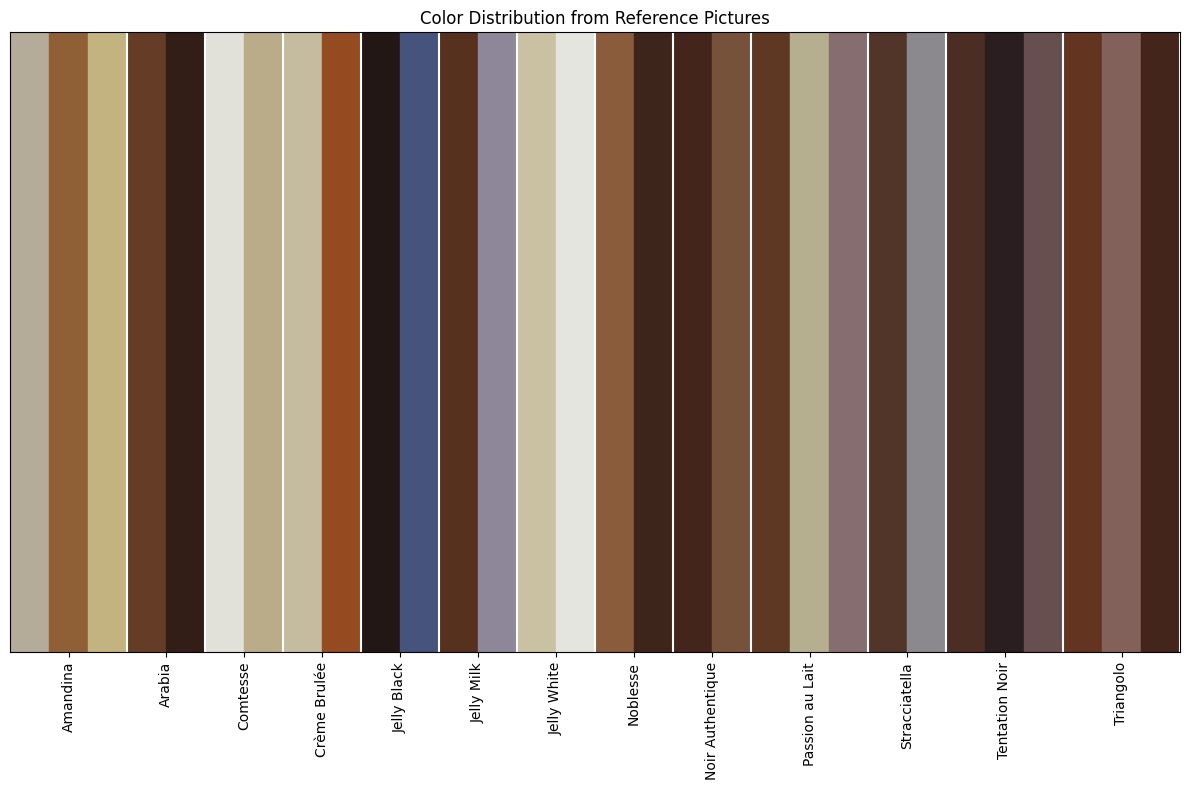

In [22]:
plot_rgb_distribution(color_data)

In [ ]:
#folder to save the preprocessed images
output_folder = "../dataset_project_iapr2025/train_preprocessed"

#folder to be accessed for the train set
dataset_path = "../dataset_project_iapr2025/train"

#Replacement color for the background for the masks
replacement_color = (183, 181, 184) 

/Users/sinarollin/Desktop/-/MA/MA3/IAPR/Project/Willy_Wonkas_Deep_Learning_Oompa-Loompas/project/src/functions_preprocessing1.py:139: RuntimeWarning: overflow encountered in scalar subtract
  max(hsv[1] - tolerance[1], 0),
/Users/sinarollin/Desktop/-/MA/MA3/IAPR/Project/Willy_Wonkas_Deep_Learning_Oompa-Loompas/project/src/functions_preprocessing1.py:145: RuntimeWarning: overflow encountered in scalar add
  min(hsv[2] + tolerance[2], 255)
/Users/sinarollin/Desktop/-/MA/MA3/IAPR/Project/Willy_Wonkas_Deep_Learning_Oompa-Loompas/project/src/functions_preprocessing1.py:138: RuntimeWarning: overflow encountered in scalar subtract
  max(hsv[0] - tolerance[0], 0),


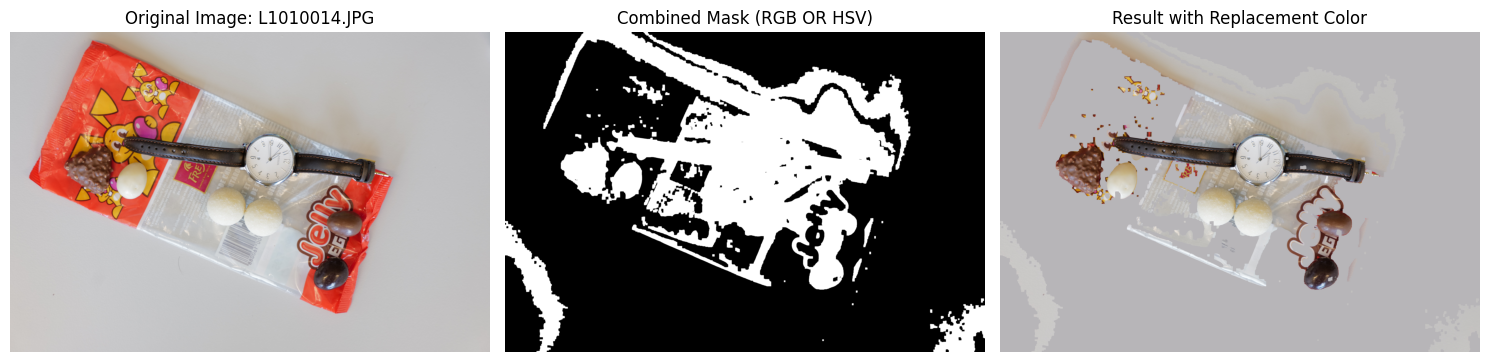

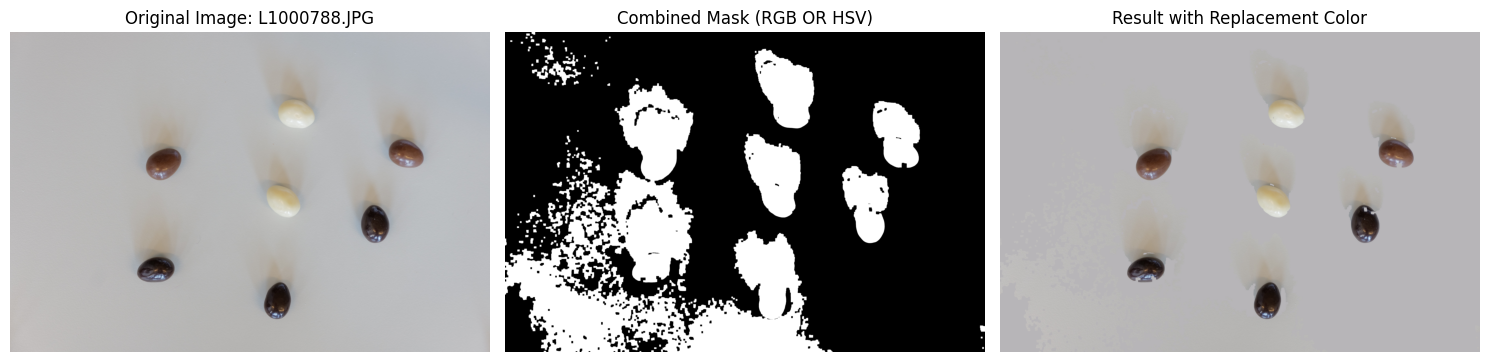

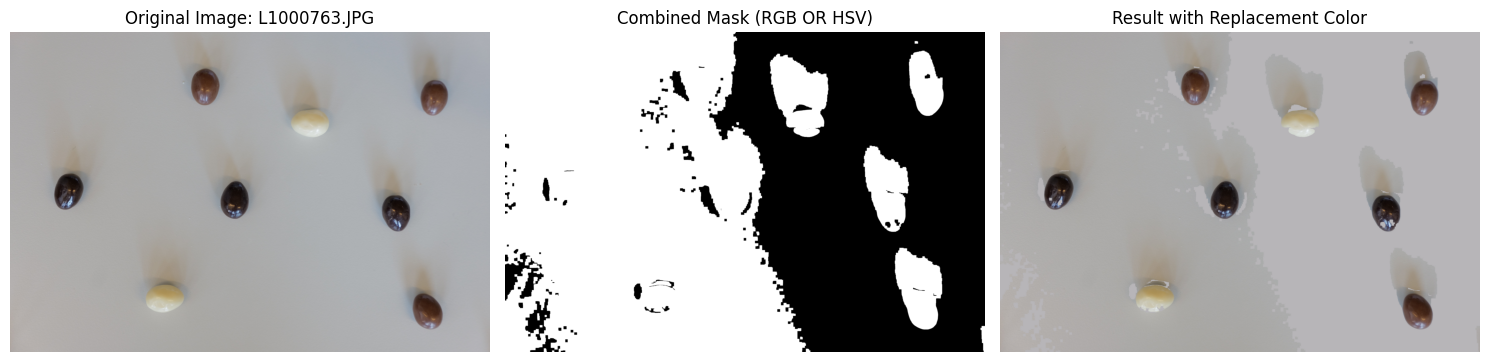

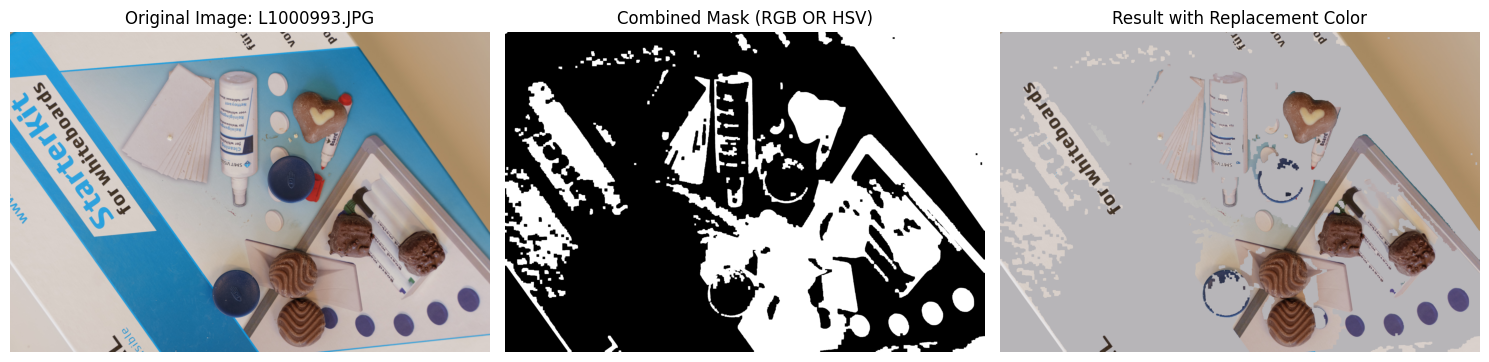

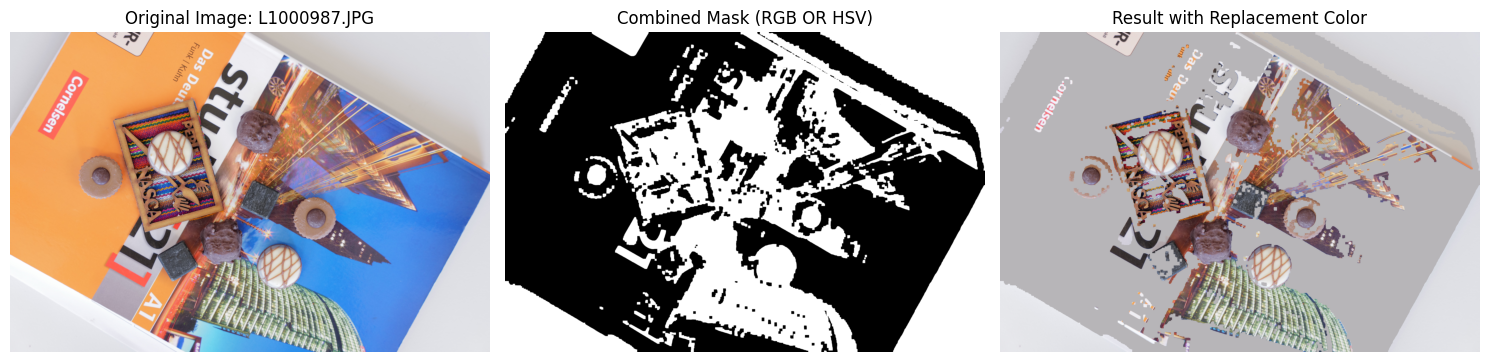

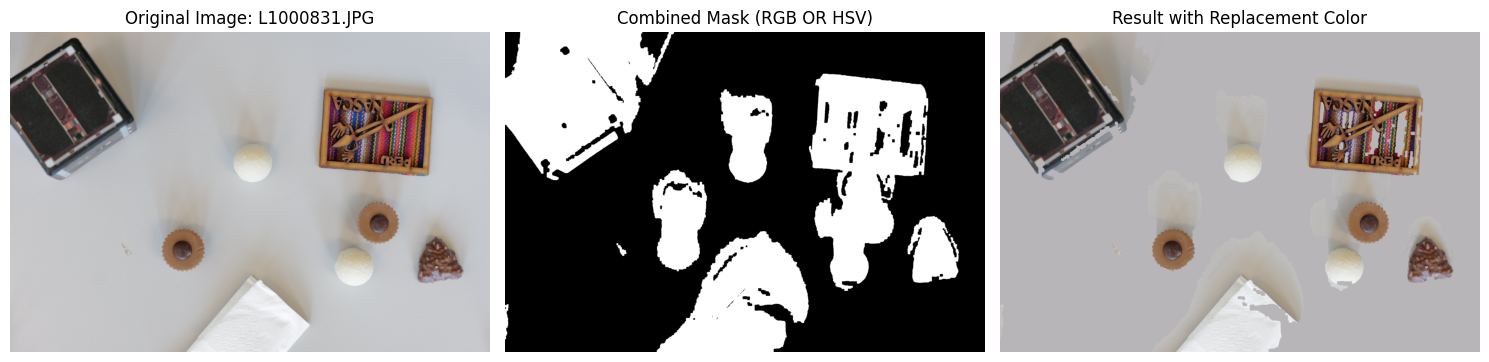

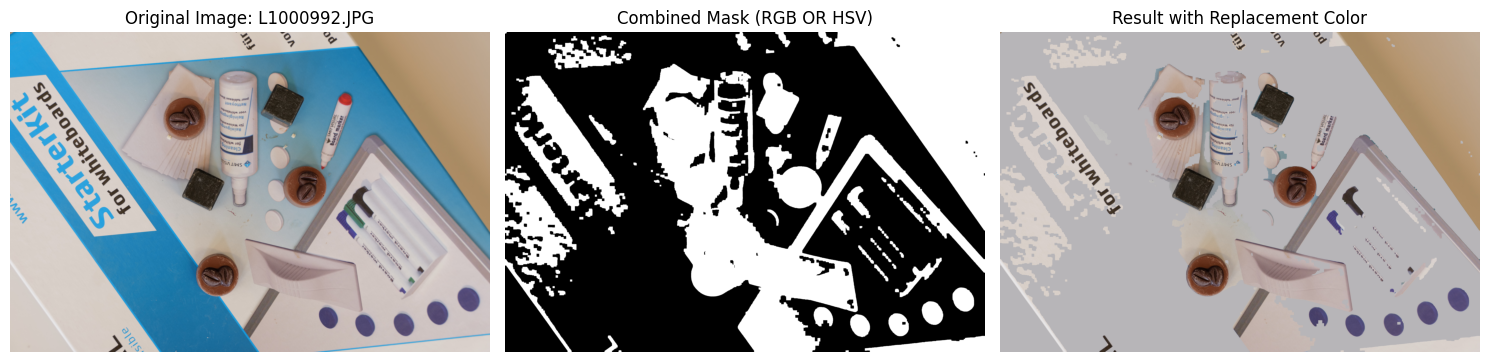

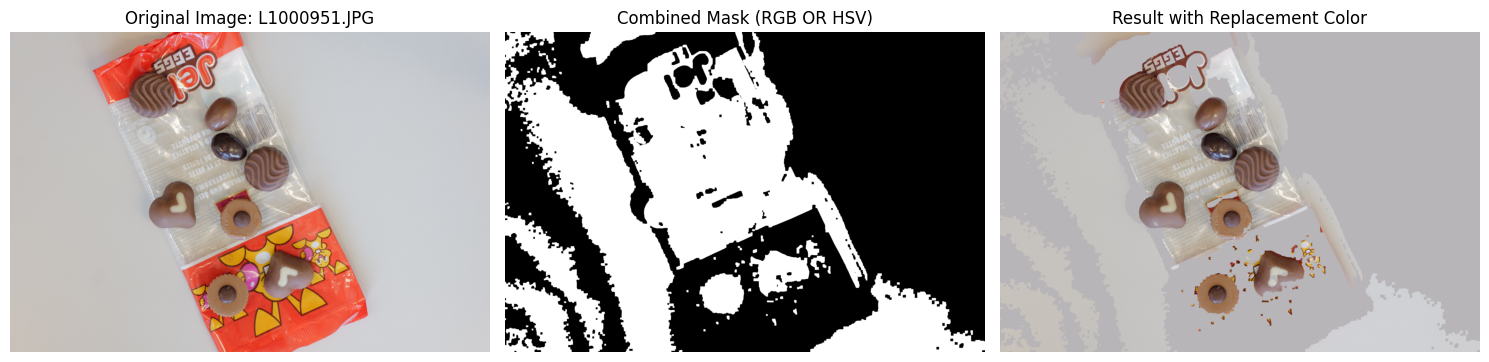

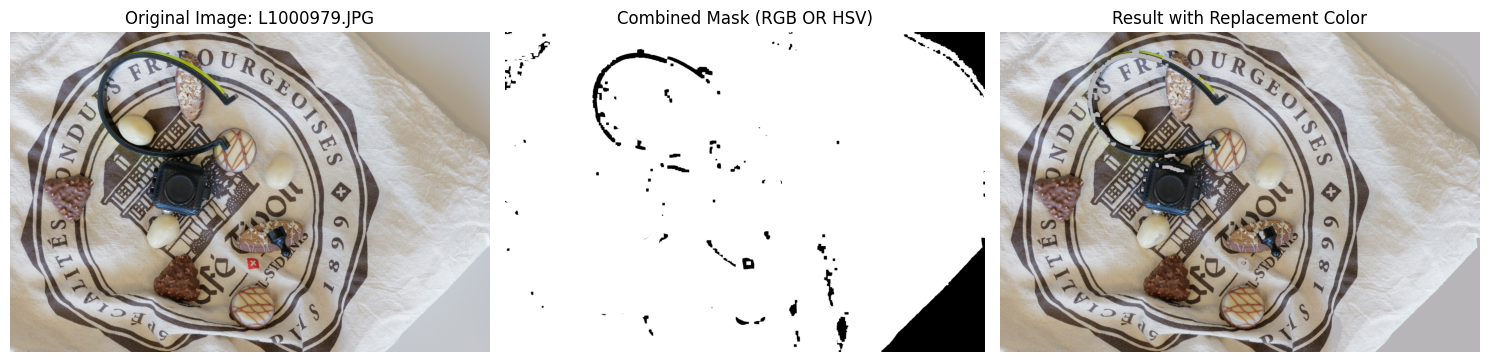

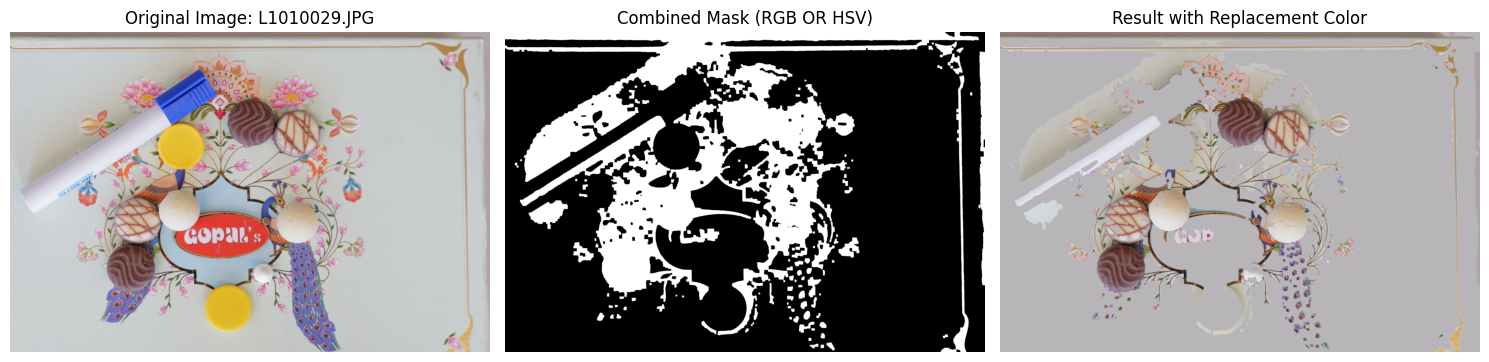

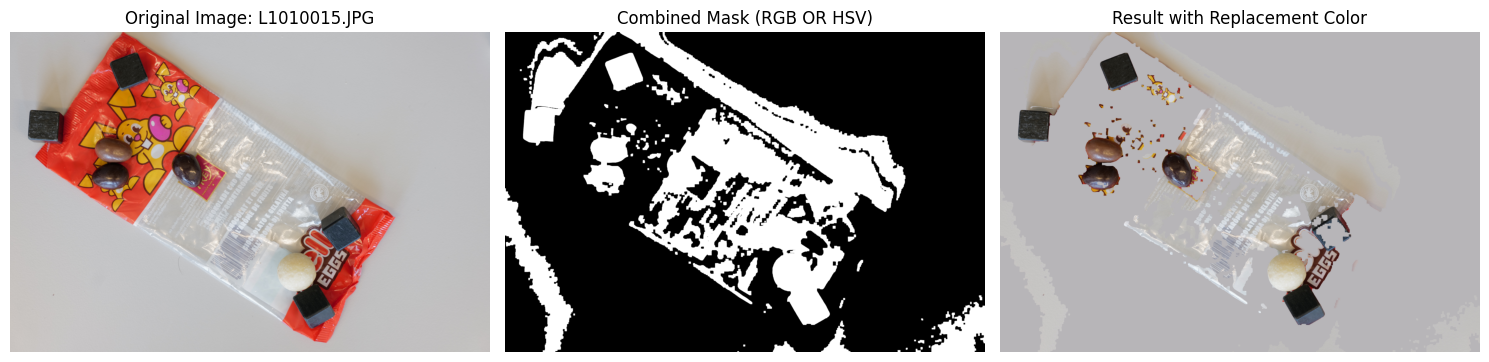

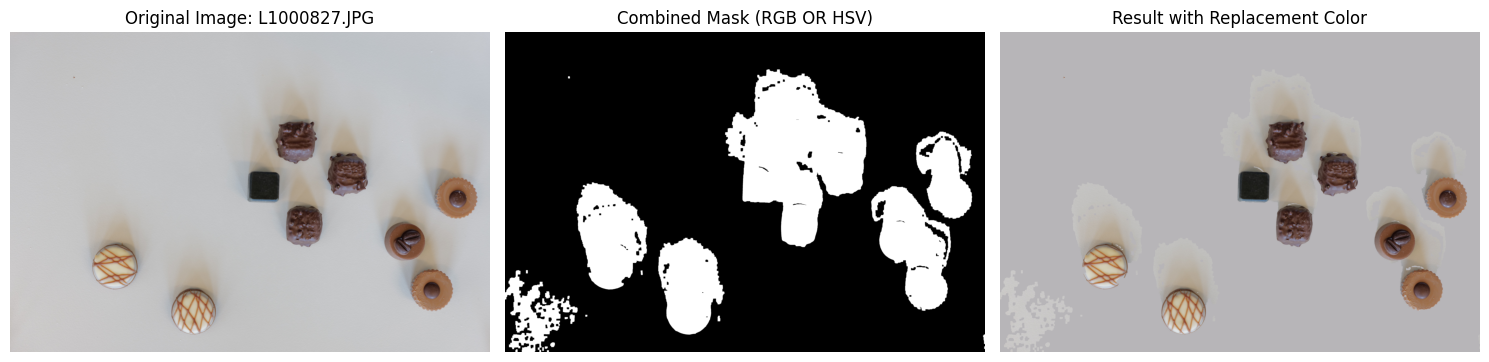

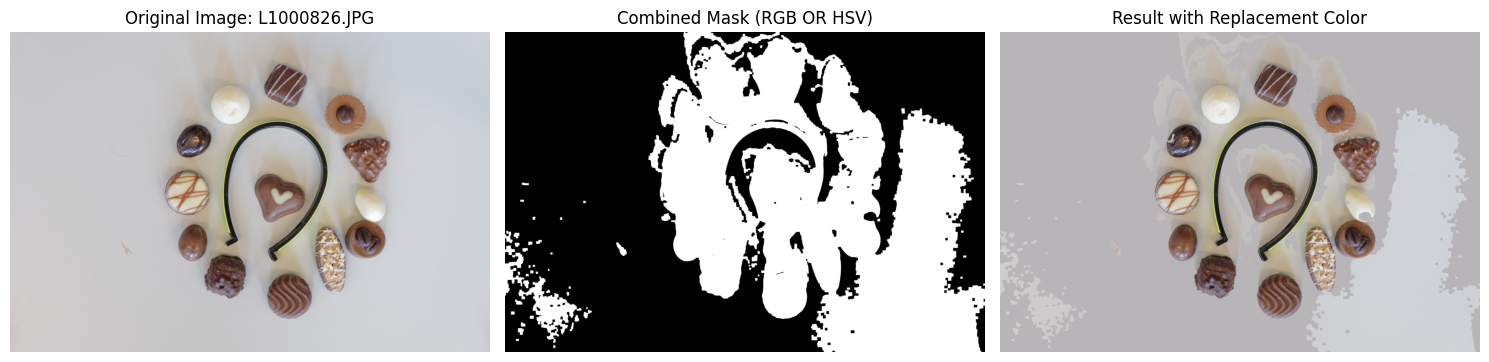

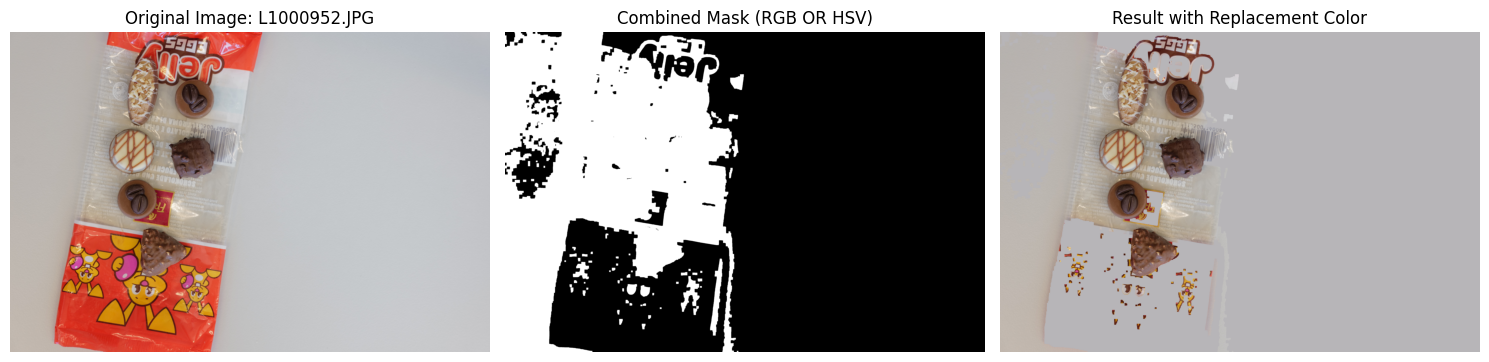

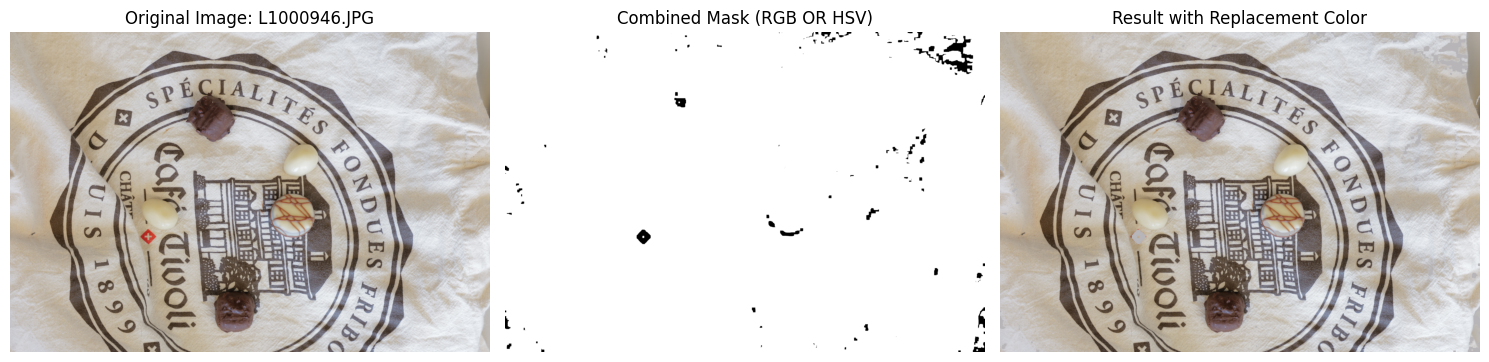

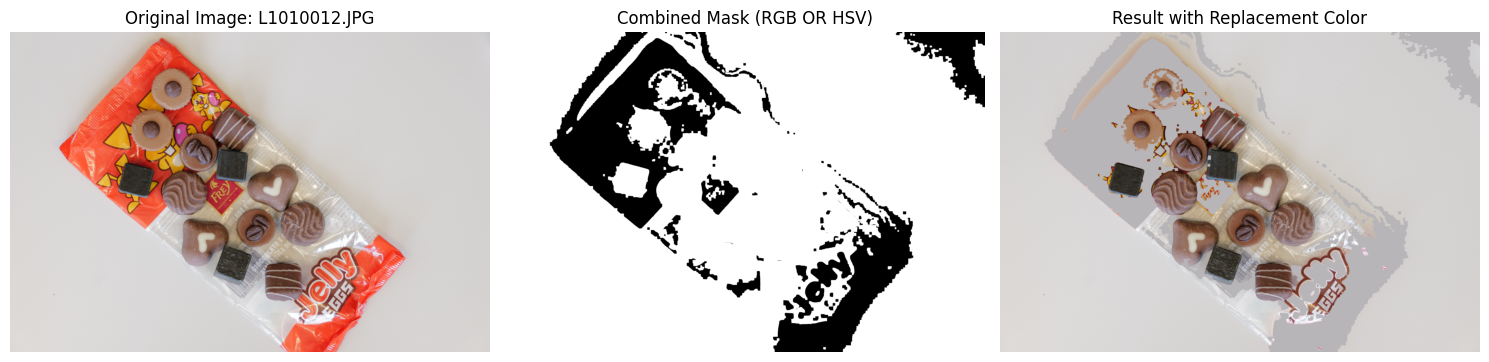

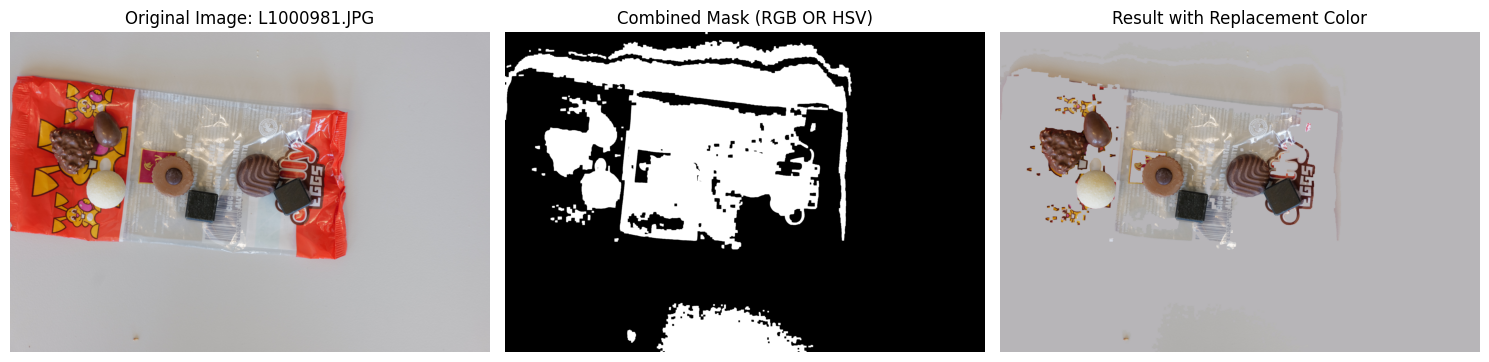

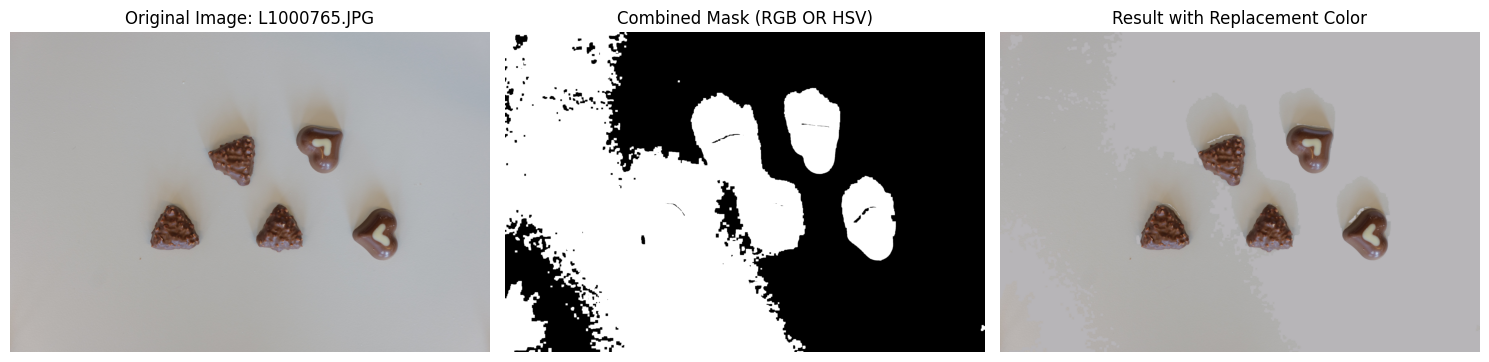

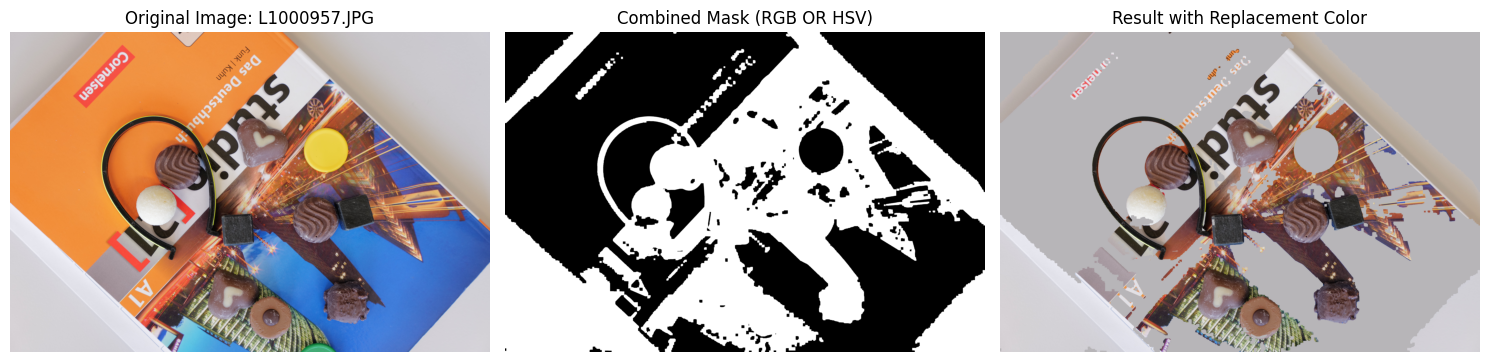

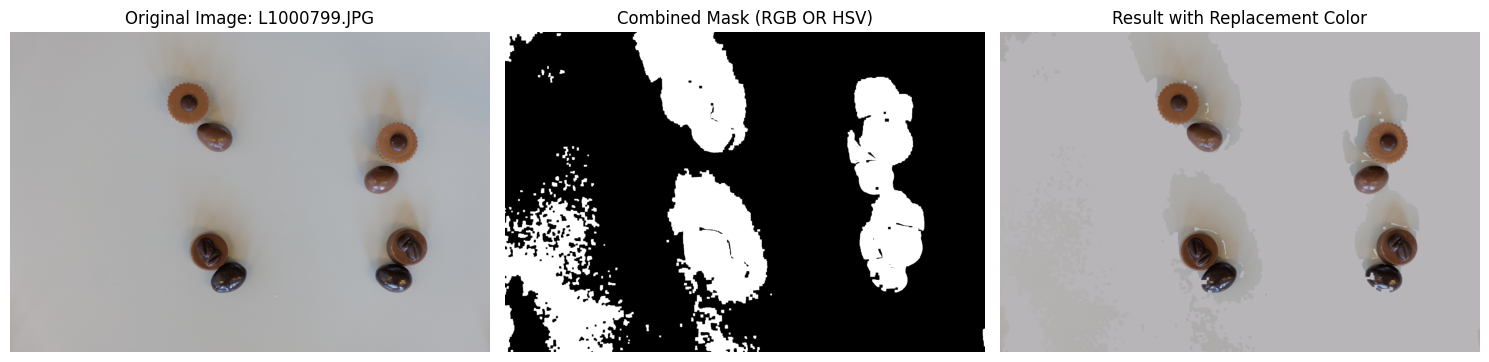

KeyboardInterrupt: 

In [24]:
# Doing both RGB and HSV

for filename in os.listdir(dataset_path):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_path = os.path.join(dataset_path, filename)
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask_rgb = create_combined_mask_rgb(image_rgb, color_data, tolerance=(15,15,15))

        mask_hsv = create_combined_mask_hsv(image, color_data, tolerance=(5, 40, 30))


        combined_mask = cv2.bitwise_or(mask_rgb, mask_hsv)

        result = image_rgb.copy()
        result[np.where(combined_mask == 0)] = replacement_color

        # # Save the processed image to the output folder
        output_path = os.path.join(output_folder, filename)
        result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)  # Convert back to BGR for saving
        cv2.imwrite(output_path, result_bgr)

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(image_rgb)
        plt.title(f"Original Image: {filename}")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(combined_mask, cmap="gray")
        plt.title("Combined Mask (RGB OR HSV)")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(result)
        plt.title("Result with Replacement Color")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

### Preprocessing 2

This part allows to 

Processing image... Jelly_Black.JPG
Processing image... Noir_authentique.JPG
Processing image... Jelly_Milk.JPG
Processing image... Creme_brulee.JPG
Processing image... Tentation_noir.JPG
Processing image... Arabia.JPG
Processing image... Passion_au_lait.JPG
Processing image... Jelly_White.JPG
Processing image... Amandina.JPG
Processing image... Triangolo.JPG
Processing image... Stracciatella.JPG
Processing image... Comtesse.JPG
Processing image... Noblesse.JPG
Saved cleaned prototype for Jelly_Black
Saved cleaned prototype for Noir_authentique
Saved cleaned prototype for Jelly_Milk
Saved cleaned prototype for Creme_brulee
Saved cleaned prototype for Tentation_noir
Saved cleaned prototype for Arabia
Saved cleaned prototype for Passion_au_lait
Saved cleaned prototype for Jelly_White
Saved cleaned prototype for Amandina
Saved cleaned prototype for Triangolo
Saved cleaned prototype for Stracciatella
Saved cleaned prototype for Comtesse
Saved cleaned prototype for Noblesse


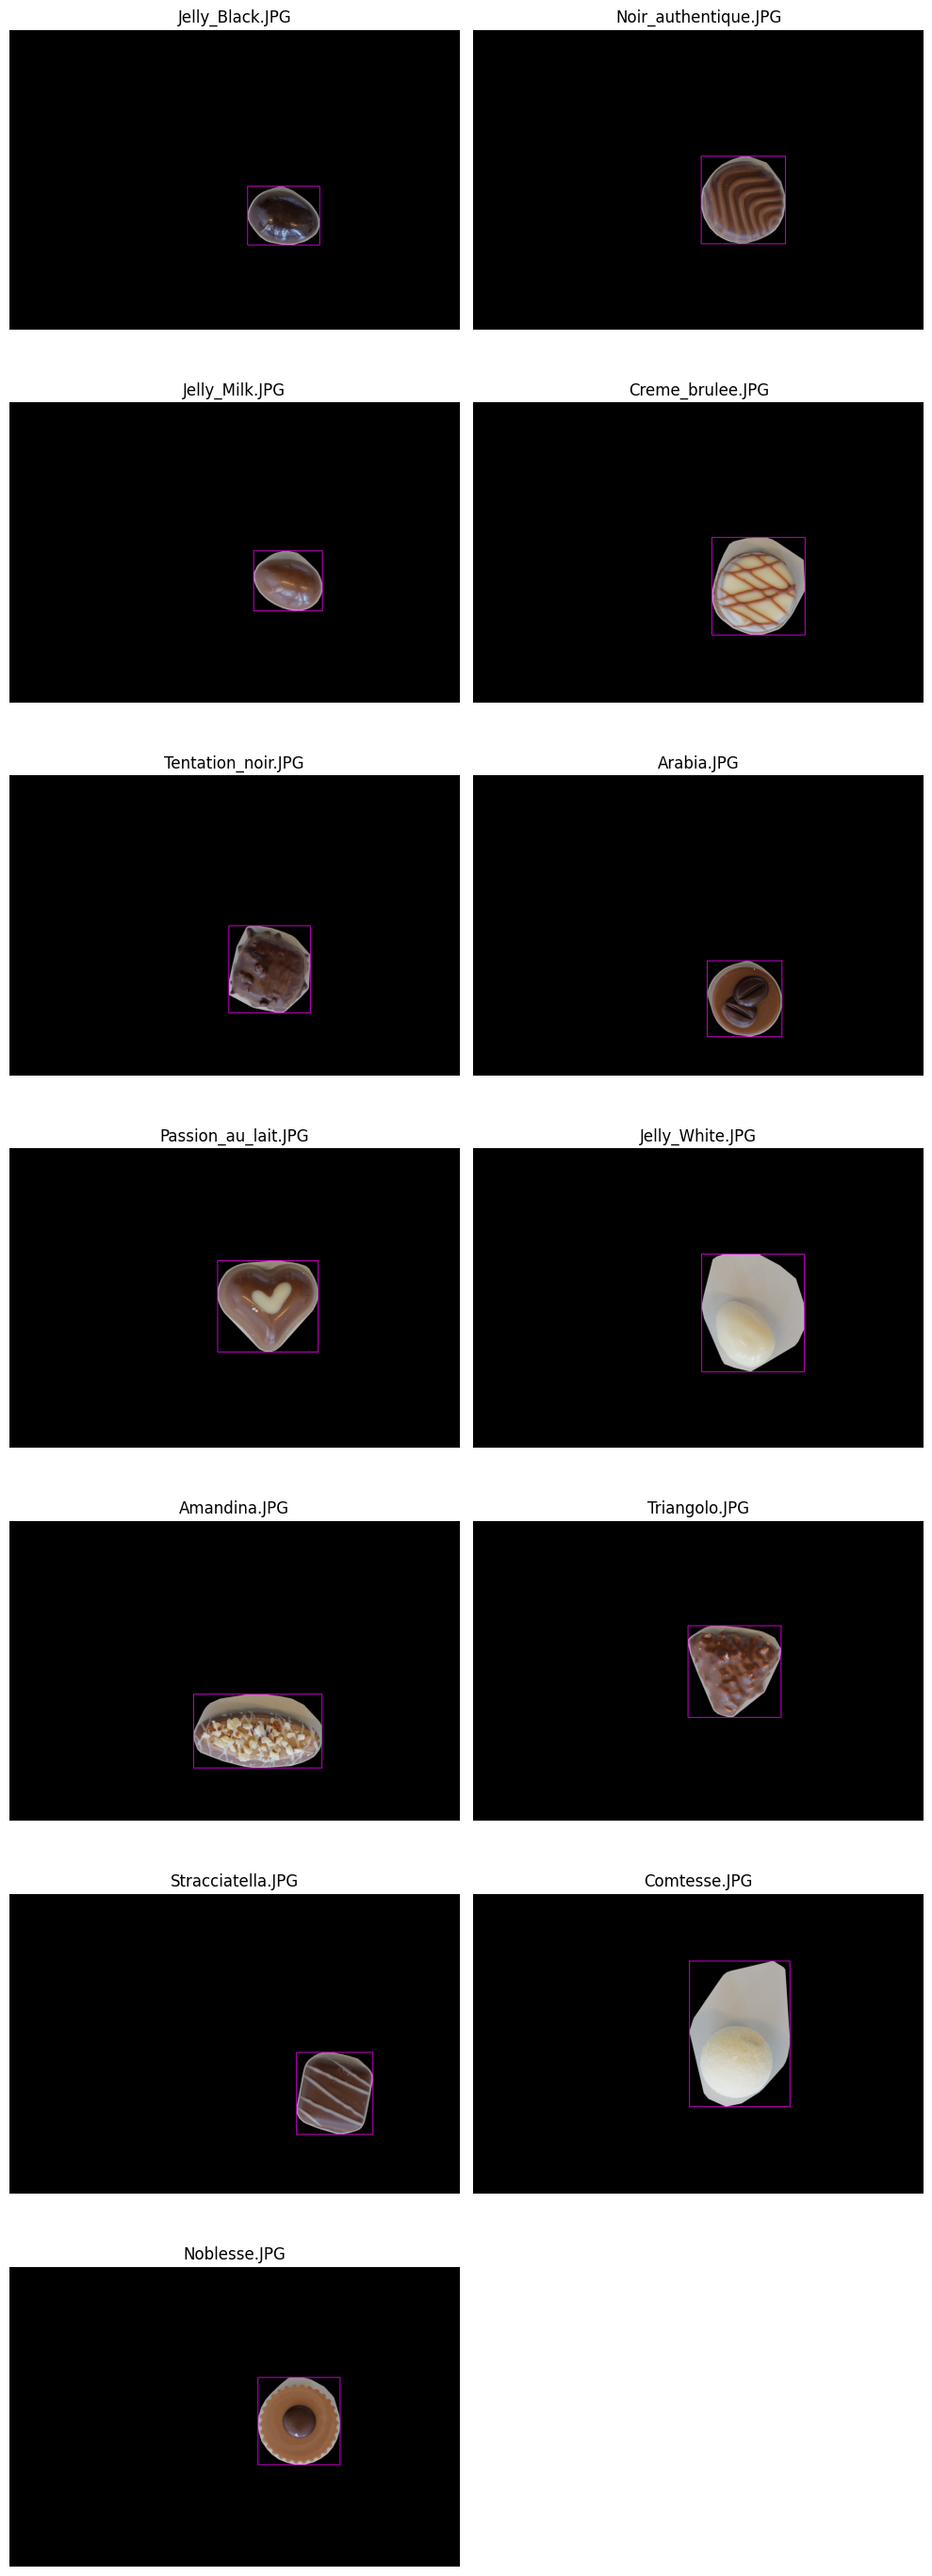

In [39]:

folder = '../dataset_project_iapr2025/references'
clean_REF_DIR = '../dataset_project_iapr2025/clean_references'
image_files = [
    fn for fn in os.listdir(folder)
    if fn.lower().endswith(('.jpg', '.jpeg'))
]
results = []

for fn in image_files:
    print("Processing image...", fn)
    path = os.path.join(folder, fn)
    img = cv2.imread(path)
    # crop to the middle 
    h, w = img.shape[:2]
    img = img[h//4:3*h//4, w//4:3*w//4]
    if img is None:
        print(f"[!] Could not read {path}, skipping.")
        continue

    extracted, bbox = extract_chocolate(img)
    if extracted is None:
        print(f"[!] No chocolate detected in {fn}.")
        continue

    results.append((fn, img, extracted, bbox))

os.makedirs(clean_REF_DIR, exist_ok=True)

for fn, orig, _, (x, y, w_box, h_box) in results:
    patch = orig[y:y+h_box, x:x+w_box]
    # resize to a common size --- think about which, now 200x200
    patch = cv2.resize(patch, (200, 200), interpolation=cv2.INTER_AREA)
    name, _ = os.path.splitext(fn)
    cv2.imwrite(f'{clean_REF_DIR}{name}.png', patch)
    print(f"Saved cleaned prototype for {name}")

n = len(results)
cols = 2
rows = (n + cols - 1) // cols
plt.figure(figsize=(cols * 5, rows * 4))
for idx, (fn, orig, extr, (x, y, w, h)) in enumerate(results, 1):
    ax = plt.subplot(rows, cols, idx)
    boxed = extr.copy()#orig.copy()
    cv2.rectangle(boxed, (x, y), (x + w, y + h), (255, 0, 255), 3)
    boxed = cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)
    ax.imshow(boxed)
    ax.set_title(fn)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:

REF_DIR    = 'src/clean_references'
TEST_DIR   = '../dataset_project_iapr2025/test'
PRED_DIR   = 'test_pred'
SAMPLE_CSV = '../dataset_project_iapr2025/sample_submission.csv'
OUT_CSV    = 'submission_fused.csv'

MIN_AREA    = 10000
MORPH_KSIZE = 9

HOG_ORIENT   = 9
PIXELS_CELL  = (16,16)
CELLS_BLOCK  = (2,2)
REF_SIZE     = (128,128)

LBP_P       = 8
LBP_R       = 1
LBP_METHOD  = 'uniform'
LBP_N_BINS  = LBP_P + 2

H_BINS      = 50
V_BINS      = 50

SIM_THRESH  = 0.6

# mapping sample cols → ref filenames
col_to_ref = {
  "Jelly White":"Jelly_White",   "Jelly Milk":"Jelly_Milk",
  "Jelly Black":"Jelly_Black",   "Amandina":"Amandina",
  "Crème brulée":"Creme_brulee", "Triangolo":"Triangolo",
  "Tentation noir":"Tentation_noir","Comtesse":"Comtesse",
  "Noblesse":"Noblesse",         "Noir authentique":"Noir_authentique",
  "Passion au lait":"Passion_au_lait","Arabia":"Arabia",
  "Stracciatella":"Stracciatella",
}

In [6]:
ref_descs = build_ref_descriptors(
    REF_DIR, REF_SIZE, HOG_ORIENT, PIXELS_CELL, CELLS_BLOCK,
    LBP_P, LBP_R, LBP_METHOD, LBP_N_BINS,
    H_BINS, V_BINS
)
classes   = list(ref_descs.keys())

Ref 'Amandina': descriptor length 1874
Ref 'Arabia': descriptor length 1874
Ref 'Comtesse': descriptor length 1874
Ref 'Creme_brulee': descriptor length 1874
Ref 'Jelly_Black': descriptor length 1874
Ref 'Jelly_Milk': descriptor length 1874
Ref 'Jelly_White': descriptor length 1874
Ref 'Noblesse': descriptor length 1874
Ref 'Noir_authentique': descriptor length 1874
Ref 'Passion_au_lait': descriptor length 1874
Ref 'Stracciatella': descriptor length 1874
Ref 'Tentation_noir': descriptor length 1874
Ref 'Triangolo': descriptor length 1874


In [7]:
os.makedirs(PRED_DIR,exist_ok=True)
sample = pd.read_csv(SAMPLE_CSV)
out    = sample.copy()

for idx,row in tqdm(sample.iterrows(),total=len(sample)):
    img_id = str(row['id'])
    fn     = f"L{img_id}.jpg"
    path   = os.path.join(TEST_DIR,fn)
    if not os.path.isfile(path):
        path = os.path.join(TEST_DIR,f"L{img_id}.JPG")
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)

    cnts, vis = classify_and_draw(img, ref_descs,classes, 
                                  REF_SIZE, 
                                HOG_ORIENT, 
                                PIXELS_CELL, 
                                CELLS_BLOCK,
                                LBP_P, 
                                LBP_R, 
                                LBP_METHOD, 
                                LBP_N_BINS,
        H_BINS, V_BINS,
        SIM_THRESH
    )
    # fill out
    for sub_col, ref_key in col_to_ref.items():
        out.at[idx, sub_col] = int(cnts.get(ref_key,0))

    cv2.imwrite(os.path.join(PRED_DIR,fn), vis)

out.to_csv(OUT_CSV,index=False)

  0%|          | 0/180 [00:00<?, ?it/s]

  4%|▍         | 8/180 [00:02<00:51,  3.35it/s]


KeyboardInterrupt: 

In [15]:
y_true = pd.read_csv(r'../dataset_project_iapr2025/train.csv',index_col='id')
y_true.to_csv('train_pred.csv', index=True)
# y_true.to_csv('train_pred.csv', index=True)
train_veronika = pd.read_csv('submission_fused.csv',index_col='id')

F1 = custom_f1_score(y_true.head(30).values,train_veronika.head(30).values)

In [16]:
F1

np.float64(0.1640962726076828)

### Fourier Descriptors and Classification

In [17]:
REF_DIR         = 'src/clean_references'
TEST_IMAGE      = r'../dataset_project_iapr2025/train/L1010035.JPG'  #L1000757
MIN_AREA        = 100000 # remove tiny specks
MAX_AREA        = 300000 # remove big objects
MORPH_KSIZE     = 9
HIST_CHANNELS   = [0, 2] # Hue & Value
HIST_BINS       = [50, 50]
HIST_RANGES     = [0, 180, 0, 256]  
HIST_METHOD     = cv2.HISTCMP_CORREL # correlation metric



print(">> Loading reference histograms …")
refs = load_reference_hists(REF_DIR,HIST_BINS, HIST_CHANNELS, HIST_RANGES)
print(f">> Found {len(refs)} reference histograms")

img = cv2.imread(TEST_IMAGE)
if img is None:
    raise IOError(f"Cannot load {TEST_IMAGE}")
pieces = segment_pieces(img)
print(f">> Found {len(pieces)} pieces")

for mask, (x, y, w_box, h_box), contour in pieces:
    patch = img[y:y+h_box, x:x+w_box]
    submask = mask[y:y+h_box, x:x+w_box]
    cls_H, score_H = classify_piece_by_hist(patch, submask, refs, HIST_BINS, HIST_CHANNELS,HIST_RANGES, HIST_METHOD)
    color_H = (255, 0, 0)
    label_H = f"{cls_H} ({score_H:.2f})"

    cv2.rectangle(img, (x, y), (x+w_box, y+h_box), color_H, 2)
    cv2.putText(img, label_H, (x, y - 100),
                cv2.FONT_HERSHEY_SIMPLEX, 4, color_H, 2, cv2.LINE_AA)
    
    contour_F_norm = get_fourier_descriptors(contour,normalize=True)
    contour_F_unnorm = get_fourier_descriptors(contour,normalize=False)
    cls_F, score_F = classify_piece_by_F_desc(contour_F_norm, refs)
    color_F = (0, 255, 0)
    label_F = f"{cls_F} ({score_F:.2f})"

    cv2.rectangle(img, (x, y), (x+w_box, y+h_box), color_F, 2)
    cv2.putText(img, label_F, (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 4, color_F, 2, cv2.LINE_AA)
    
    cv2.drawContours(img, contour, -1, (0, 0, 255), 2)
    complex_contour = np.fft.ifft(contour_F_unnorm)
    
    #extract x and y coordinates from the complex numbers
    x_coords = np.real(complex_contour)
    y_coords = np.imag(complex_contour)
    # Stack to shape (N, 1, 2) and convert to int32
    reconstructed_contour = np.stack((x_coords, y_coords), axis=-1)
    reconstructed_contour = np.round(reconstructed_contour).astype(np.int32)
    reconstructed_contour = reconstructed_contour.reshape((-1, 1, 2))

    cv2.drawContours(img, [reconstructed_contour], -1, (0, 0, 255), 2)

    cls, score, score_df = combined_classifier(contour_F_norm, patch, submask, refs, HIST_BINS, HIST_CHANNELS, HIST_RANGES, HIST_METHOD)
    color_C = (0, 0, 255)
    label = f"{cls} ({score:.2f})"

    #print()
    cv2.rectangle(img, (x, y), (x+w_box, y+h_box), color_C, 2)
    cv2.putText(img, label, (x, y - 200),
                cv2.FONT_HERSHEY_SIMPLEX, 4, color_C, 2, cv2.LINE_AA)

""" for contour in contours:
    cls, score = classify_piece_by_F_desc(contour, ref_Fs)
    color = (0, 255, 0)
    label = f"{cls} ({score:.2f})"

    cv2.rectangle(img, (x, y), (x+w_box, y+h_box), color, 2)
    cv2.putText(img, label, (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 4, color, 2, cv2.LINE_AA) """


plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Histogram-based classification")
plt.show()

>> Loading reference histograms …


TypeError: object of type 'NoneType' has no len()

In [7]:
REF_DIR         = 'src/clean_references'
TEST_DIR        = r'../dataset_project_iapr2025/test'  #L1000757


print(">> Loading reference histograms …")
refs = load_reference_hists(REF_DIR,HIST_BINS, HIST_CHANNELS, HIST_RANGES)

sub = pd.read_csv(r'../dataset_project_iapr2025/sample_submission.csv', index_col='id')
#sub = pd.read_csv(r'dataset_project_iapr2025\train.csv',index_col='id')*0
count = 0

for fn in sorted(os.listdir(TEST_DIR)):
    count += 1
    #if count > 30:
    #    continue
    """ if not fn.lower().endswith('.JPG'):
        continue """
    cls_name = os.path.splitext(fn)[0]
    print(cls_name)
    img = cv2.imread(os.path.join(TEST_DIR, fn))

    if img is None:
        raise IOError(f"Cannot load {os.path.join(TEST_DIR, fn)}")
    pieces = segment_pieces(img)
    print(f">> Found {len(pieces)} pieces")


    nb_choc = 0
    for mask, (x, y, w_box, h_box), contour in pieces:
        patch = img[y:y+h_box, x:x+w_box]
        submask = mask[y:y+h_box, x:x+w_box]
        contour_F_norm = get_fourier_descriptors(contour,normalize=True)
        cls, score, _ = combined_classifier(contour_F_norm, patch, submask, refs, HIST_BINS, HIST_CHANNELS, HIST_RANGES, HIST_METHOD)
        #color_C = (0, 0, 255)
        
        label = f"{cls} ({score:.2f})"
        print(label)

        if cls == 'Creme_brulee':
            cls = 'Crème brulée'

        

        if score > 0.4: 
            row_id = int(cls_name[1:])
            col_name = cls.replace('_', ' ')

            if col_name in sub.columns:
                if row_id in sub.index.values:
                    sub.loc[row_id,col_name] += 1
                    nb_choc += 1
                else:
                    print(f"⚠️ No matching ID found for {cls_name[1:]}")
            else:
                print(f"⚠️ Column '{col_name}' not found in DataFrame")
    
            #print()
            cv2.rectangle(img, (x, y), (x+w_box, y+h_box), color_C, 2)
            cv2.putText(img, label, (x, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 4, color_C, 2, cv2.LINE_AA)


    if (count % 4 == 0):

        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title("Histogram-based classification")
        plt.show()

    print(f">> Found {nb_choc} chocolates")
        

    

>> Loading reference histograms …
L1000757
>> Found 0 pieces
>> Found 0 chocolates
L1000758
>> Found 5 pieces


AttributeError: 'NoneType' object has no attribute 'items'

In [ ]:
## YOUR CODE
...